<a href="https://www.kaggle.com/code/lalit7881/indian-developer-burnout-dataset-eda?scriptVersionId=320820049" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shambhurajejagadale/indian-developer-burnout-and-layoff-anxiety-dataset/indian_developer_burnout_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shambhurajejagadale/indian-developer-burnout-and-layoff-anxiety-dataset/indian_developer_burnout_2026.csv")

In [3]:
df.head()

,developer_id,age,gender,city,state,marital_status,education_level,company_type,company_size,job_role,...,layoff_anxiety_score,ai_replacement_fear_score,job_security_confidence,emergency_savings_months,linkedin_job_search_activity,applied_jobs_last_30_days,burnout_risk_category,likely_to_switch_job,mentally_exhausted,high_layoff_risk
0,DEV00001,31,Male,Hyderabad,Telangana,Single,M.Tech,Freelance,1-10,Backend Developer,...,5.1,4.8,7.2,3.0,Low,4,High,No,Yes,No
1,DEV00002,27,Male,Bengaluru,Karnataka,Single,B.Tech,Product-based,201-1000,DevOps Engineer,...,1.8,5.5,10.0,8.0,NaN,4,Low,No,No,No
2,DEV00003,31,Male,Delhi,Delhi,Married,B.Tech,Startup,11-50,Frontend Developer,...,5.2,3.3,5.9,7.0,Low,4,High,Maybe,Yes,No
3,DEV00004,36,Male,Pune,Maharashtra,Single,MCA,Freelance,1-10,Android Developer,...,5.2,7.0,8.1,2.0,Very High,6,High,Yes,Yes,No
4,DEV00005,27,Male,Pune,Maharashtra,Single,B.Tech,Service-based,5000+,Data Scientist,...,4.5,6.6,8.0,2.0,Very High,4,Medium,No,Yes,No


In [4]:
df.tail()

,developer_id,age,gender,city,state,marital_status,education_level,company_type,company_size,job_role,...,layoff_anxiety_score,ai_replacement_fear_score,job_security_confidence,emergency_savings_months,linkedin_job_search_activity,applied_jobs_last_30_days,burnout_risk_category,likely_to_switch_job,mentally_exhausted,high_layoff_risk
4995,DEV04996,28,Male,Chennai,Tamil Nadu,Single,B.Sc CS,Freelance,1-10,Data Engineer,...,5.2,7.7,7.2,1.0,High,7,Medium,Maybe,Yes,No
4996,DEV04997,32,Female,Noida,Uttar Pradesh,Single,B.Tech,Service-based,5000+,Full Stack Developer,...,4.1,3.4,6.3,1.0,Low,7,Medium,No,No,No
4997,DEV04998,44,Female,Kolkata,West Bengal,Married,B.Tech,Product-based,51-200,Full Stack Developer,...,6.4,5.9,7.0,9.0,Medium,2,Medium,No,No,No
4998,DEV04999,32,Male,Chennai,Tamil Nadu,Single,MCA,Startup,11-50,DevOps Engineer,...,1.8,3.6,8.5,6.0,High,8,Low,Maybe,No,No
4999,DEV05000,24,Male,Indore,Madhya Pradesh,Married,BCA,Service-based,201-1000,Android Developer,...,6.3,7.1,6.5,7.0,High,5,Low,No,No,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   developer_id                        5000 non-null   object 
 1   age                                 5000 non-null   int64  
 2   gender                              5000 non-null   object 
 3   city                                5000 non-null   object 
 4   state                               5000 non-null   object 
 5   marital_status                      5000 non-null   object 
 6   education_level                     5000 non-null   object 
 7   company_type                        5000 non-null   object 
 8   company_size                        5000 non-null   object 
 9   job_role                            5000 non-null   object 
 10  employment_type                     5000 non-null   object 
 11  experience_years                    5000 no

In [6]:
df.describe()

,age,experience_years,salary_lpa,years_in_current_company,remote_work_ratio,weekly_work_hours,number_of_switches,ai_tools_usage_hours_per_week,upskilling_hours_per_week,leetcode_problems_solved,...,caffeine_intake_per_day,work_life_balance_rating,imposter_syndrome_score,social_media_usage_hours,physical_activity_days_per_week,layoff_anxiety_score,ai_replacement_fear_score,job_security_confidence,emergency_savings_months,applied_jobs_last_30_days
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,4875.000000,4875.000000,...,4875.000000,5000.000000,5000.00000,4875.000000,5000.000000,5000.00000,5000.000000,5000.000000,4875.000000,5000.000000
mean,28.245200,5.418680,26.979186,1.927240,45.309800,48.115960,2.192800,5.13384,4.967836,134.717128,...,2.743590,6.877640,5.16682,2.869272,2.638600,4.25390,5.189700,7.222940,5.517538,4.620400
std,4.794213,4.369203,16.132555,1.527937,31.813026,10.033851,1.477858,4.65854,4.785292,123.670909,...,1.642649,1.630233,1.51496,2.133841,1.636253,1.51491,1.763183,1.379341,4.776525,2.843575
min,21.000000,0.500000,3.500000,0.100000,0.000000,30.000000,0.000000,0.00000,0.000000,1.000000,...,0.000000,1.100000,1.00000,0.200000,0.000000,1.00000,1.000000,2.400000,1.000000,0.000000
25%,25.000000,2.300000,16.930000,0.800000,19.000000,41.200000,1.000000,1.90000,1.400000,48.000000,...,2.000000,5.800000,4.10000,1.200000,1.000000,3.20000,4.000000,6.300000,2.000000,3.000000
50%,28.000000,4.100000,23.935000,1.500000,42.000000,47.100000,2.000000,3.70000,3.500000,95.000000,...,3.000000,6.900000,5.20000,2.200000,3.000000,4.20000,5.100000,7.300000,4.000000,4.000000
75%,31.000000,7.300000,33.612500,2.500000,76.000000,53.400000,3.000000,6.90000,6.900000,183.000000,...,4.000000,8.000000,6.20000,3.900000,4.000000,5.30000,6.400000,8.200000,8.000000,6.000000
max,48.000000,28.000000,308.490000,19.500000,100.000000,94.900000,9.000000,30.00000,25.000000,1080.000000,...,9.000000,10.000000,10.00000,8.000000,7.000000,10.00000,10.000000,10.000000,36.000000,15.000000


In [7]:
df.isnull().sum()

developer_id                            0
age                                     0
gender                                  0
city                                    0
state                                   0
marital_status                          0
education_level                         0
company_type                            0
company_size                            0
job_role                                0
employment_type                         0
experience_years                        0
salary_lpa                              0
years_in_current_company                0
promotion_last_2_years                  0
remote_work_ratio                       0
weekly_work_hours                       0
weekend_work_frequency                  0
night_shift_frequency                   0
layoffs_seen_in_company                 0
number_of_switches                      0
primary_language                        0
tech_stack                              0
ai_tools_usage_hours_per_week     

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

developer_id                           object
age                                     int64
gender                                 object
city                                   object
state                                  object
marital_status                         object
education_level                        object
company_type                           object
company_size                           object
job_role                               object
employment_type                        object
experience_years                      float64
salary_lpa                            float64
years_in_current_company              float64
promotion_last_2_years                 object
remote_work_ratio                       int64
weekly_work_hours                     float64
weekend_work_frequency                 object
night_shift_frequency                  object
layoffs_seen_in_company                object
number_of_switches                      int64
primary_language                  

In [10]:
df.columns

Index(['developer_id', 'age', 'gender', 'city', 'state', 'marital_status',
       'education_level', 'company_type', 'company_size', 'job_role',
       'employment_type', 'experience_years', 'salary_lpa',
       'years_in_current_company', 'promotion_last_2_years',
       'remote_work_ratio', 'weekly_work_hours', 'weekend_work_frequency',
       'night_shift_frequency', 'layoffs_seen_in_company',
       'number_of_switches', 'primary_language', 'tech_stack',
       'ai_tools_usage_hours_per_week', 'upskilling_hours_per_week',
       'leetcode_problems_solved', 'certifications_count',
       'side_projects_count', 'github_activity_score',
       'interview_preparation_hours_weekly', 'stress_level', 'burnout_score',
       'anxiety_score', 'sleep_hours', 'caffeine_intake_per_day',
       'work_life_balance_rating', 'imposter_syndrome_score',
       'social_media_usage_hours', 'physical_activity_days_per_week',
       'therapy_or_counseling', 'layoff_anxiety_score',
       'ai_replacement

In [11]:
df.nunique()

developer_id                          5000
age                                     26
gender                                   4
city                                    15
state                                   12
marital_status                           4
education_level                          8
company_type                             6
company_size                             6
job_role                                14
employment_type                          4
experience_years                       228
salary_lpa                            2945
years_in_current_company               100
promotion_last_2_years                   2
remote_work_ratio                       65
weekly_work_hours                      493
weekend_work_frequency                   5
night_shift_frequency                    4
layoffs_seen_in_company                  4
number_of_switches                      10
primary_language                        14
tech_stack                              32
ai_tools_us

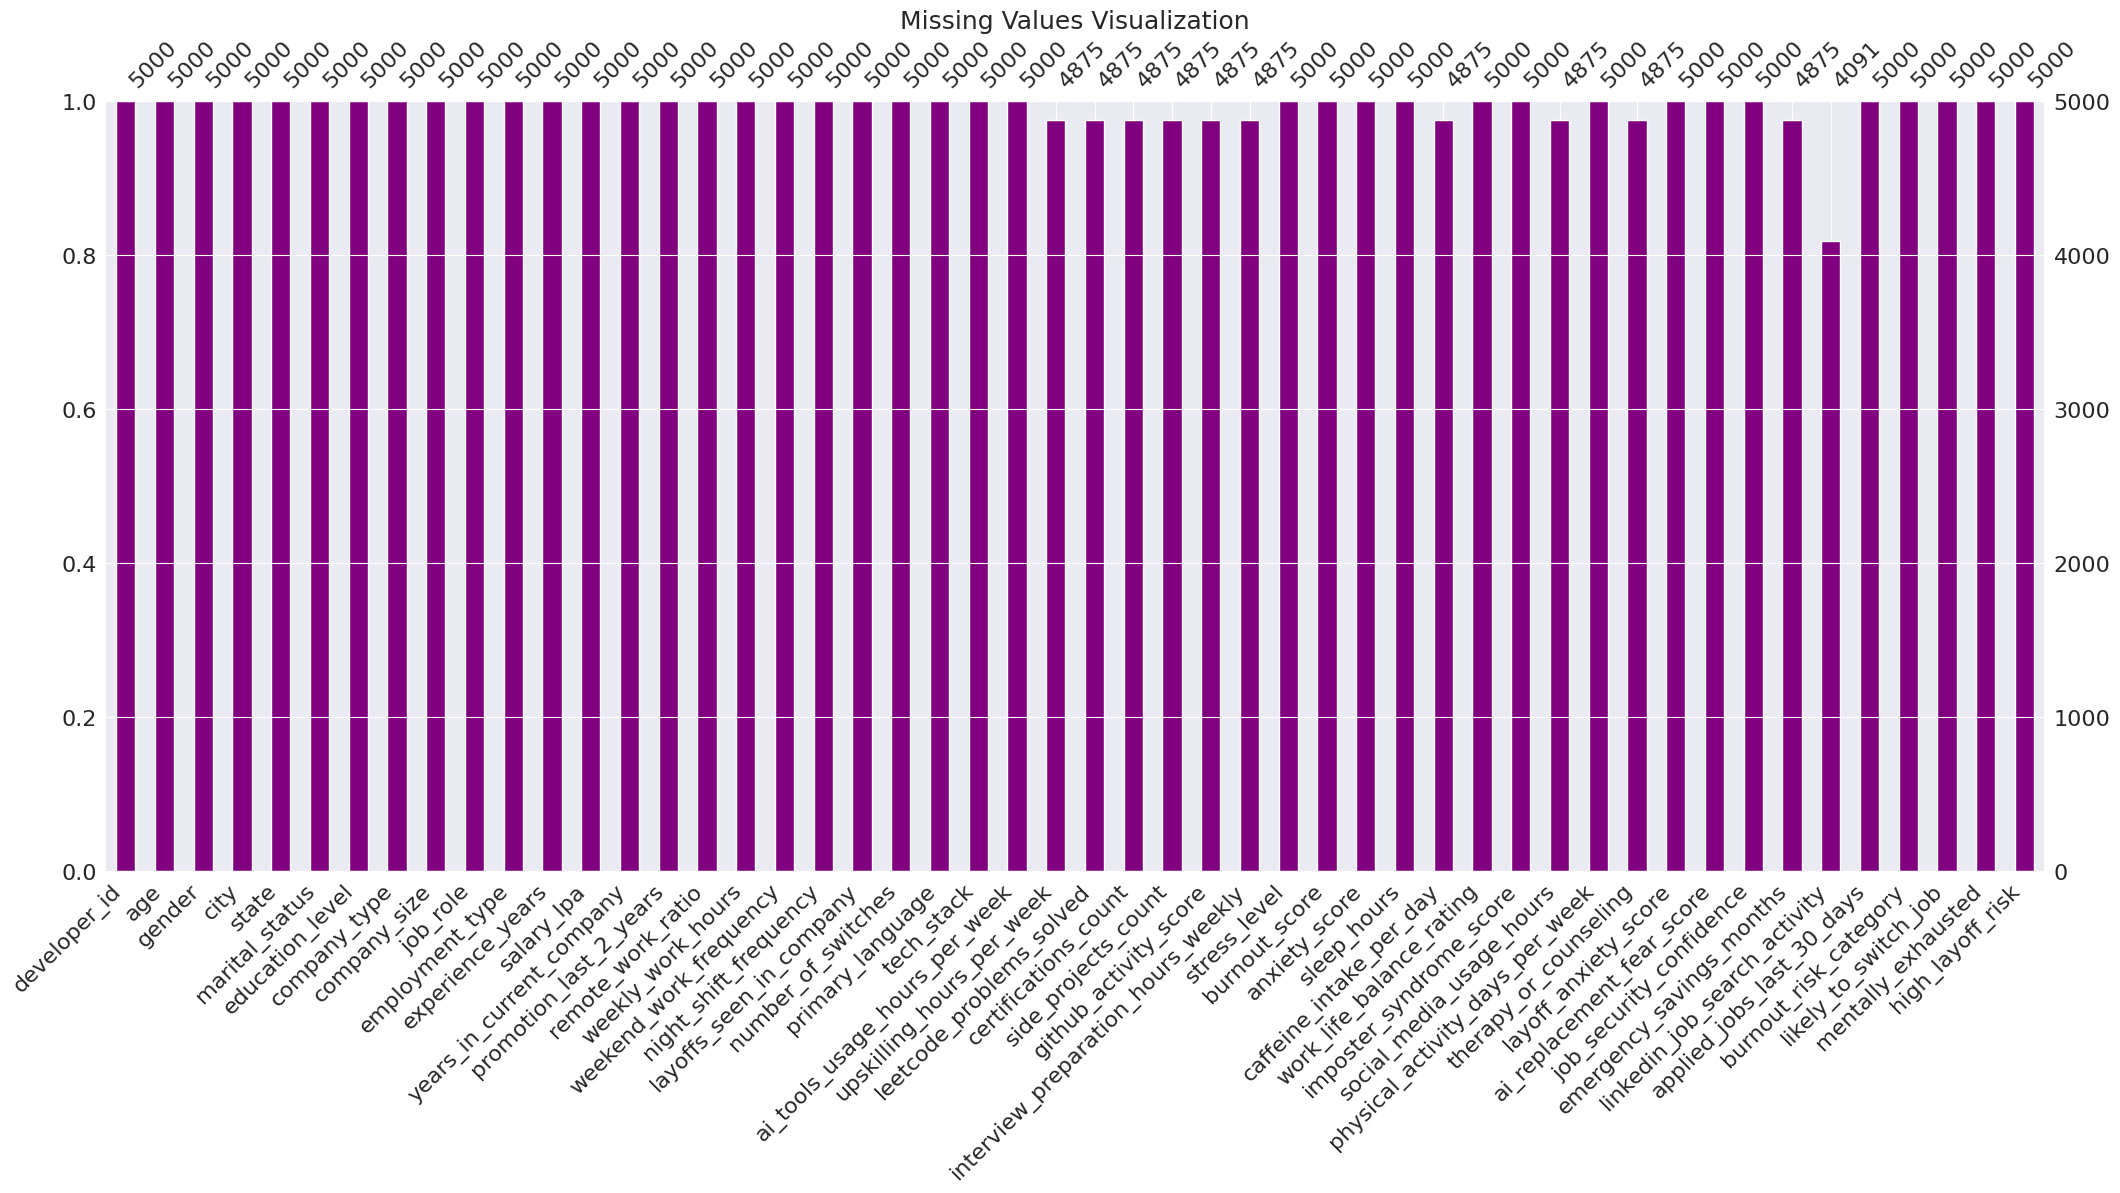

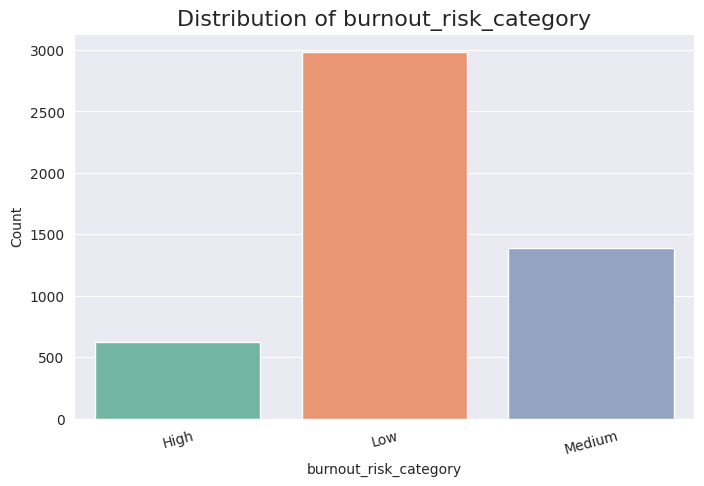

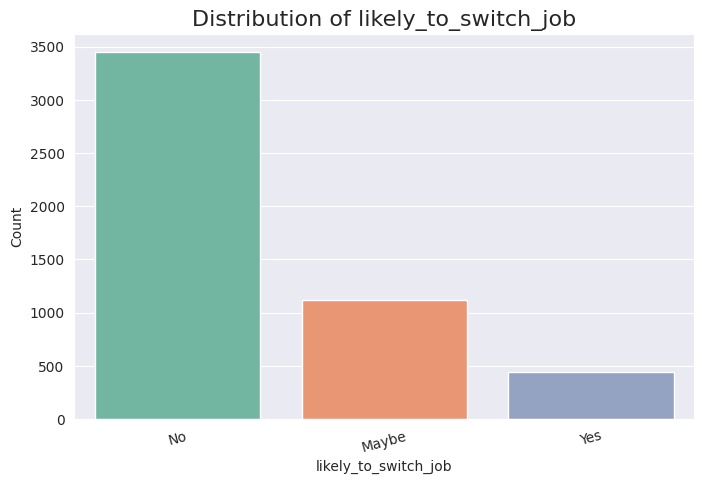

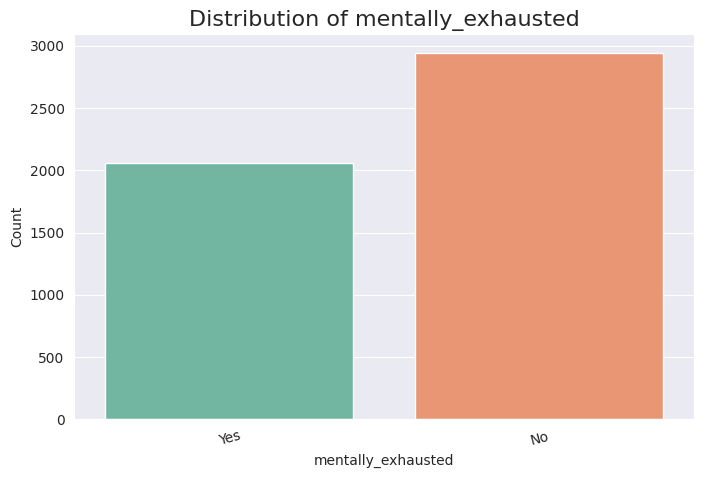

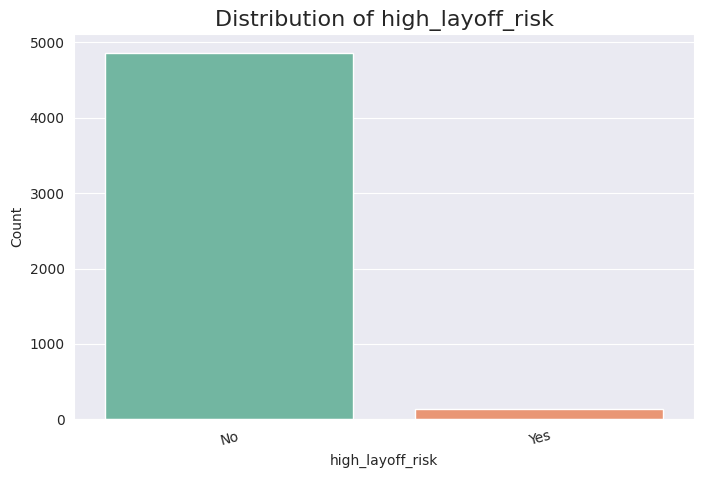

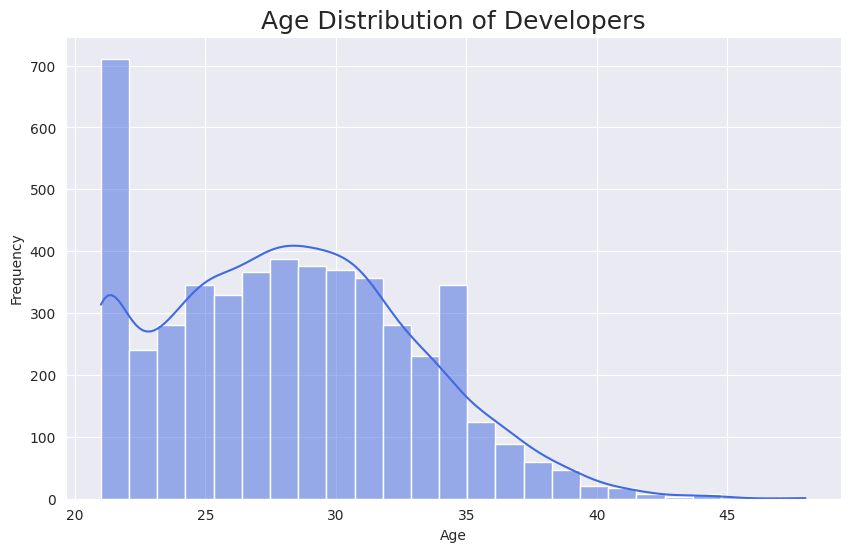

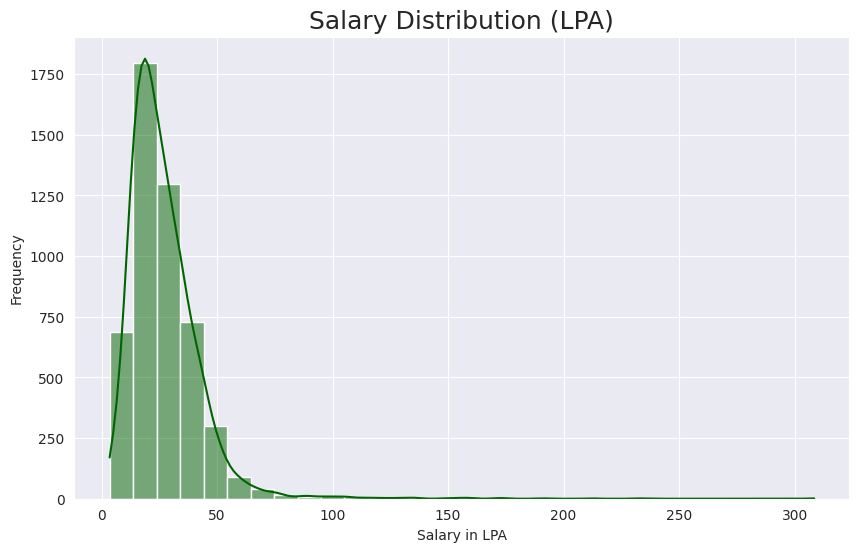

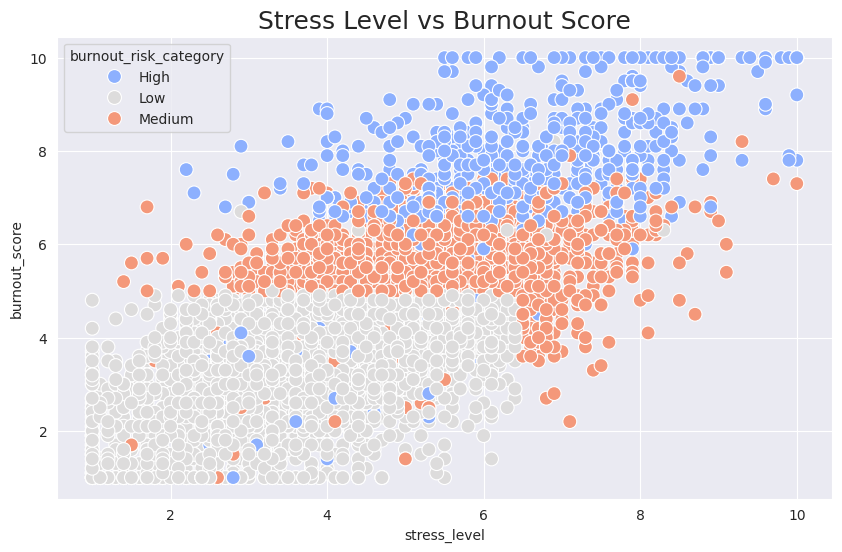

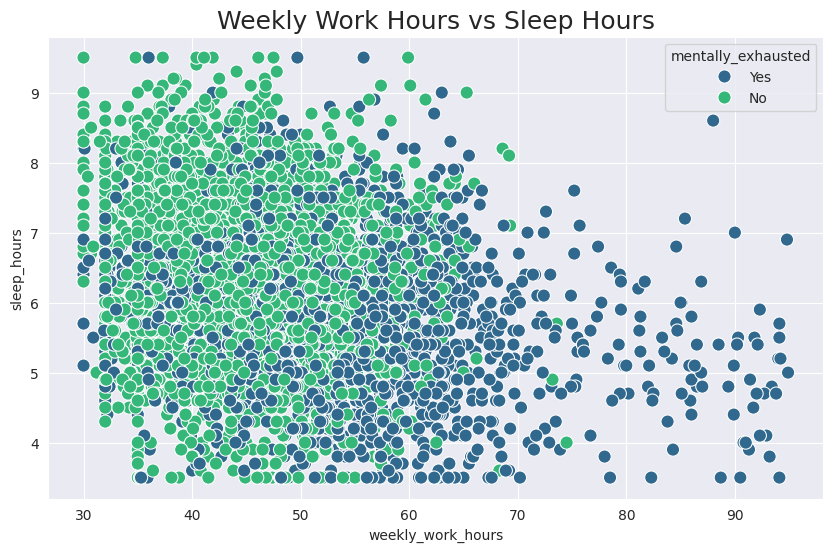

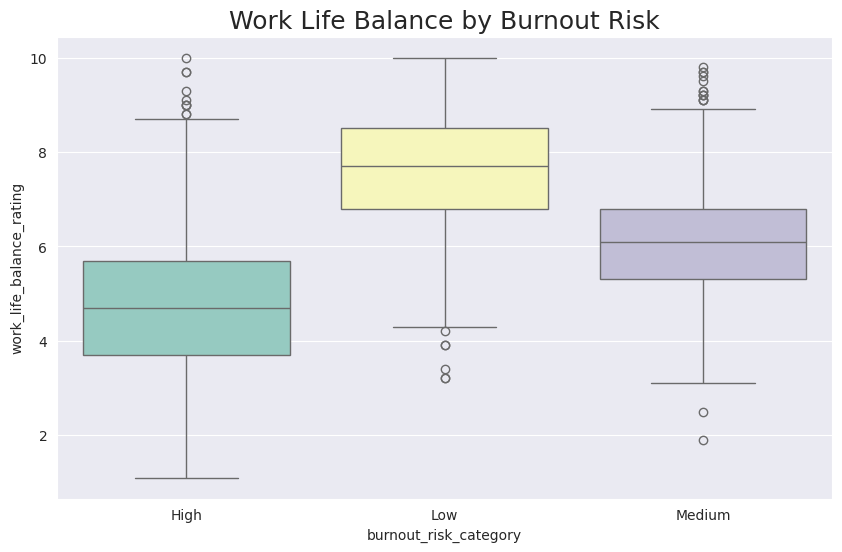

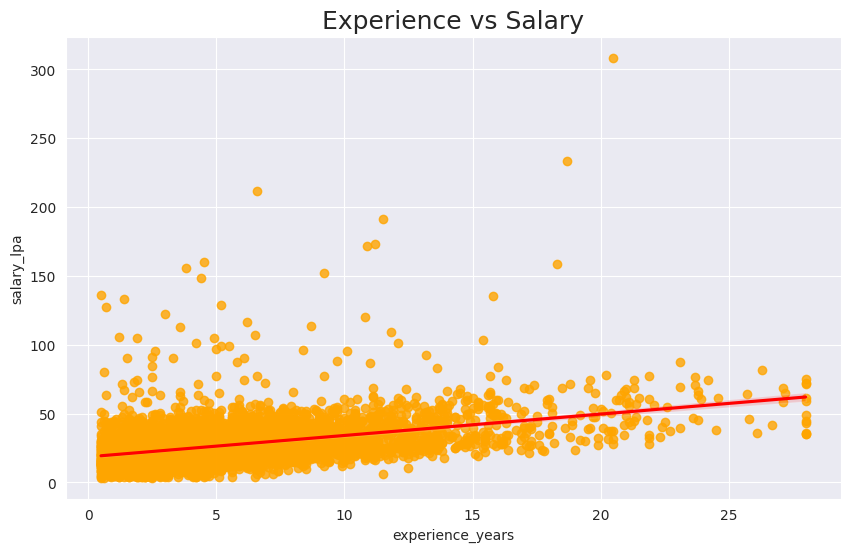

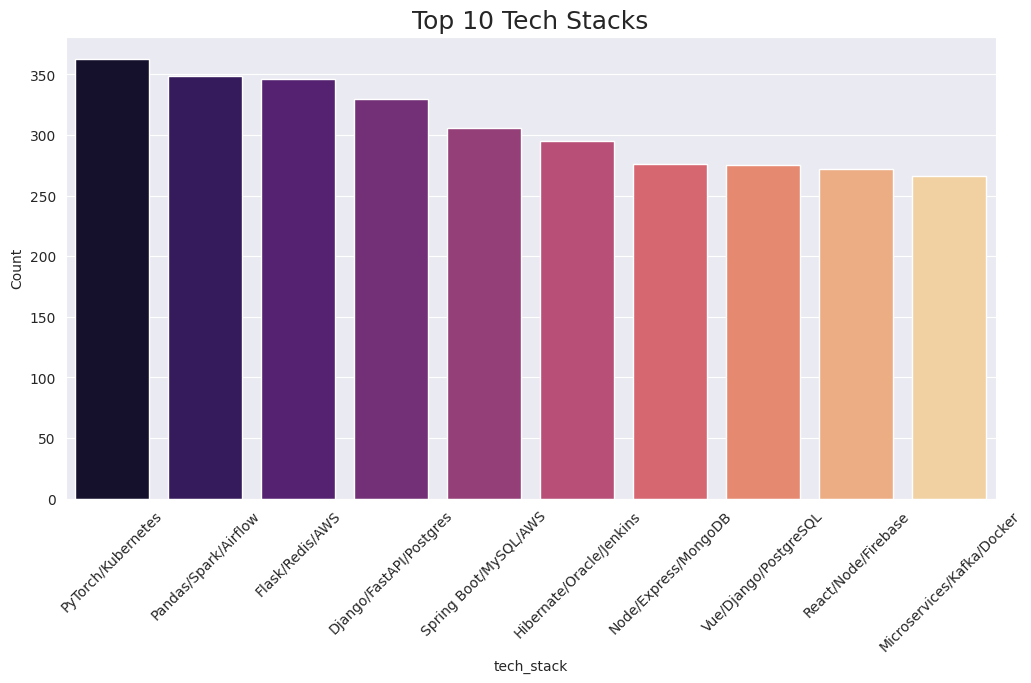

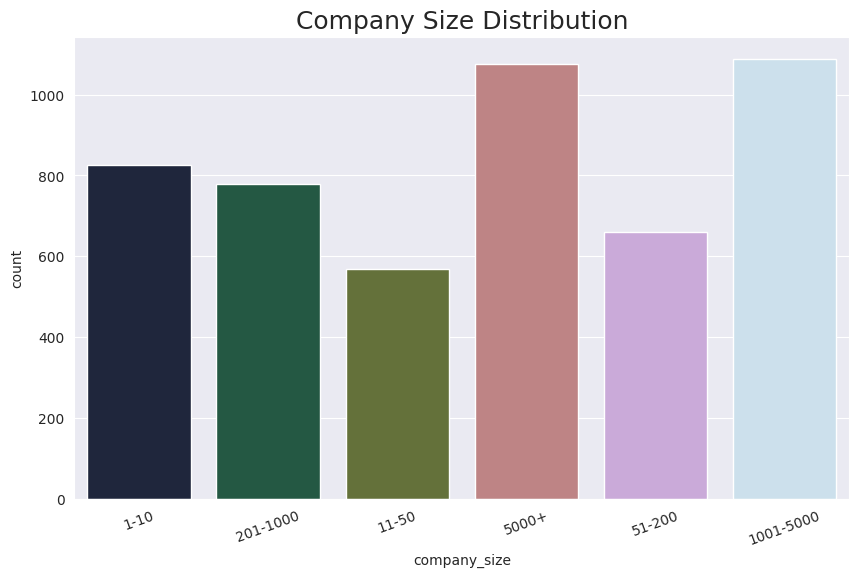

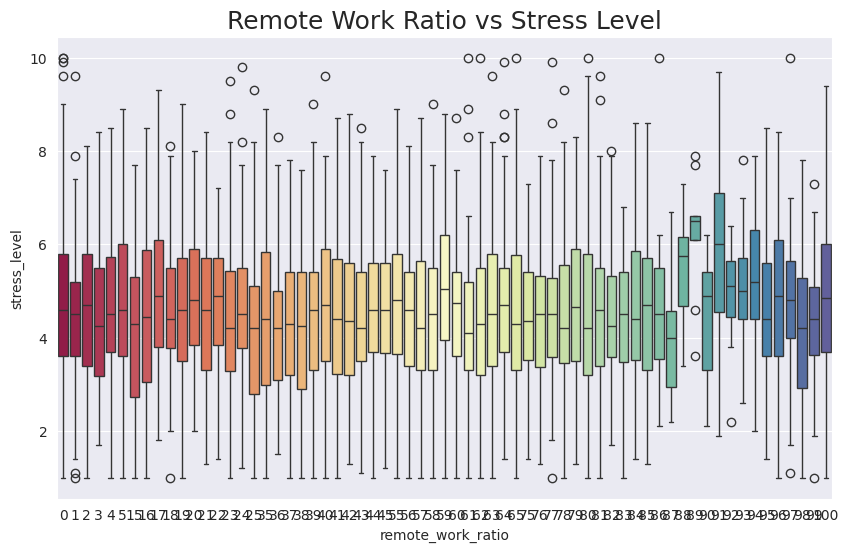

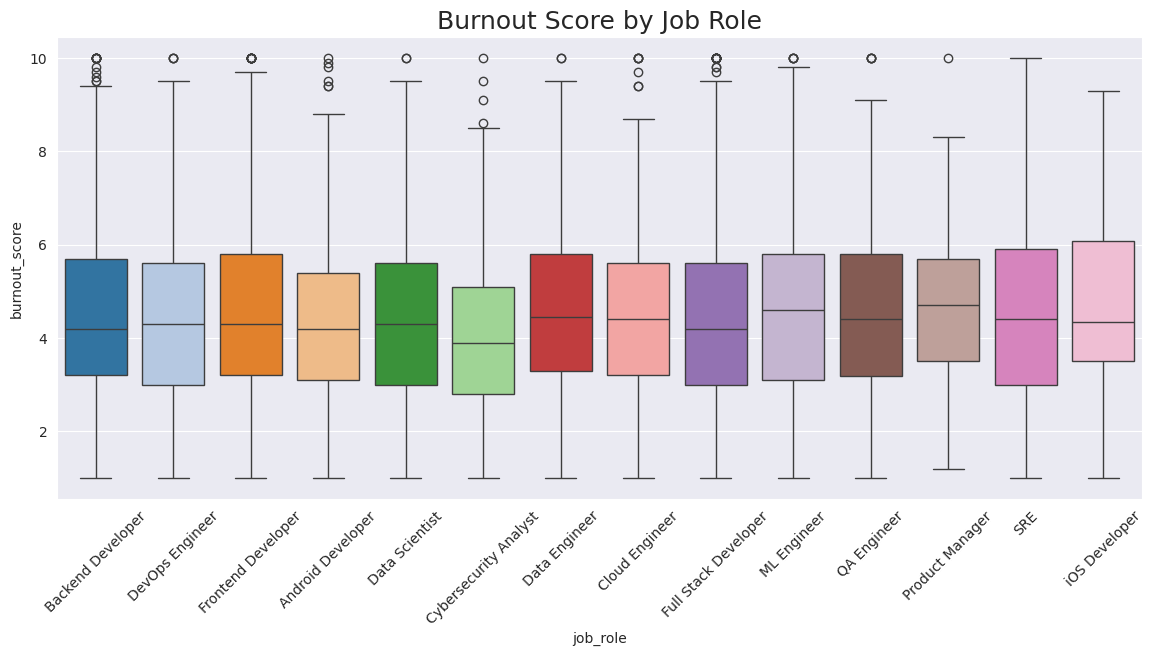

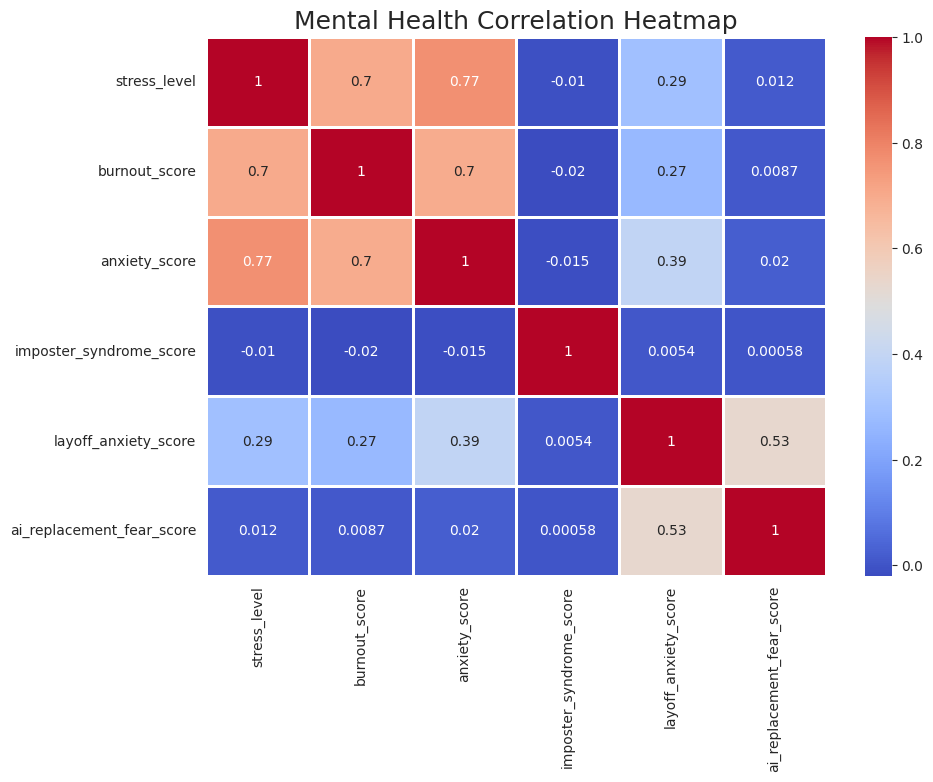

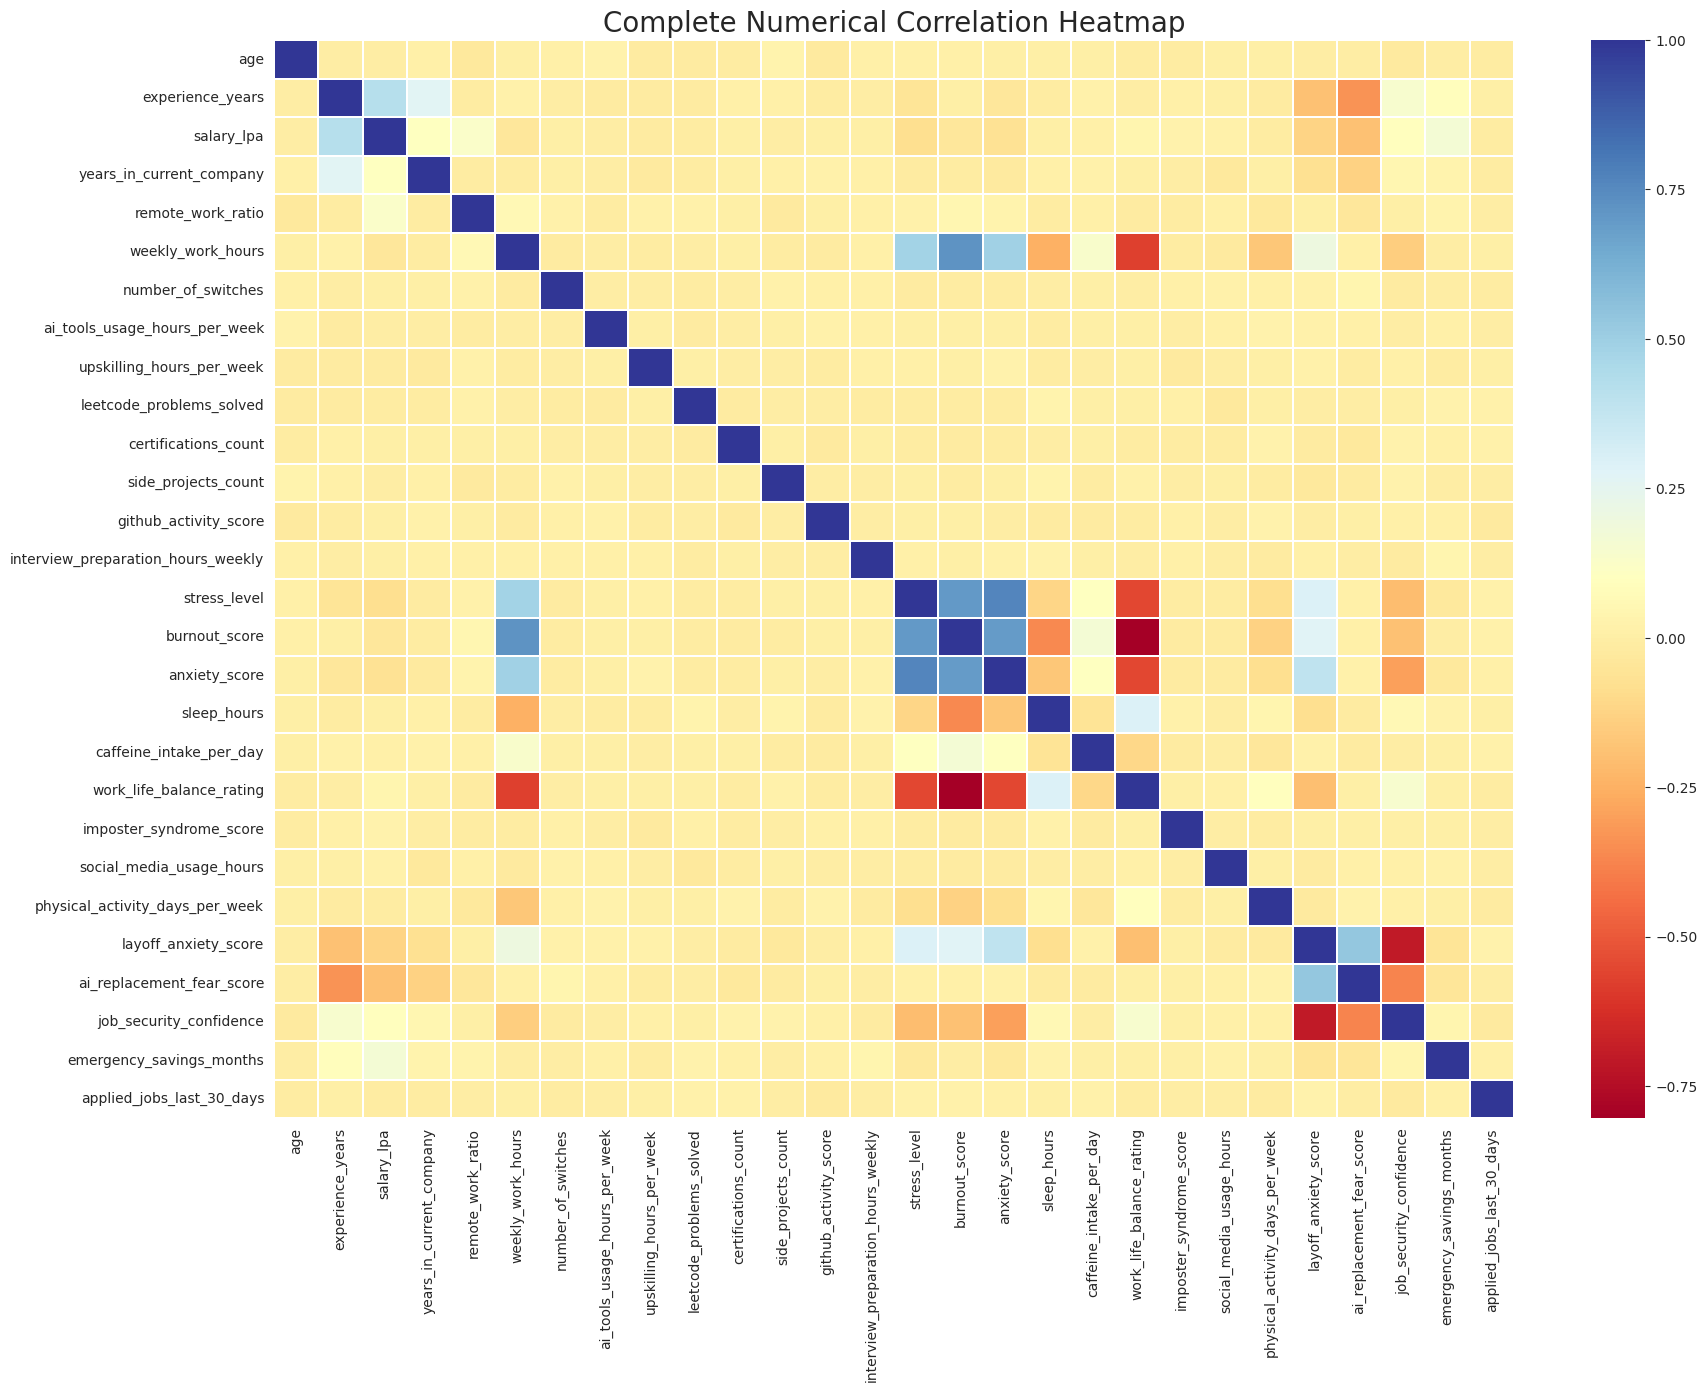

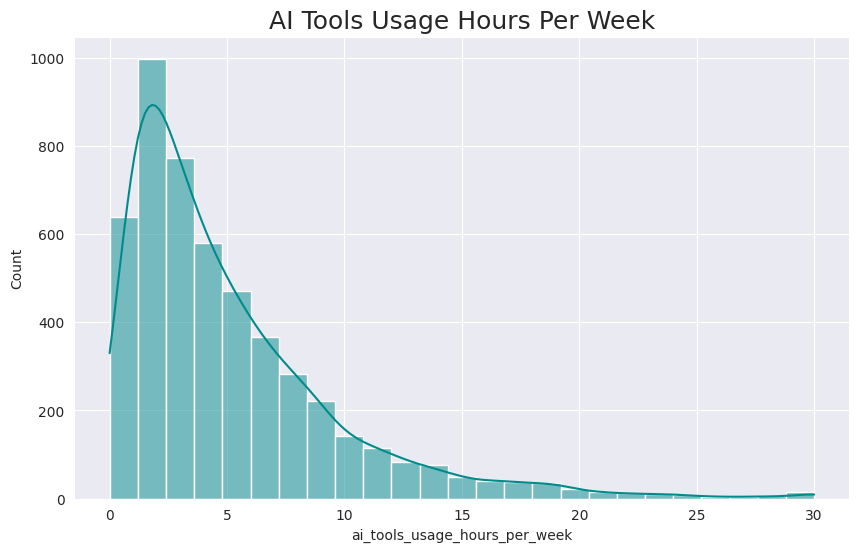

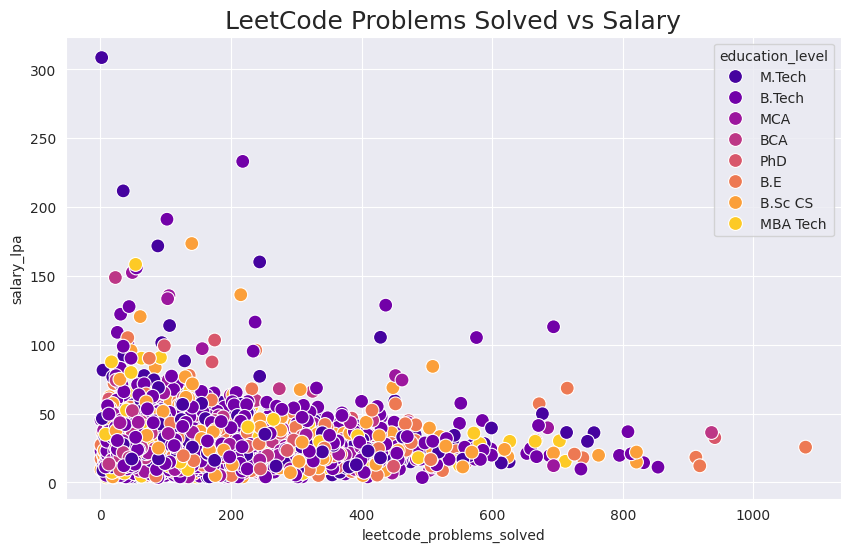

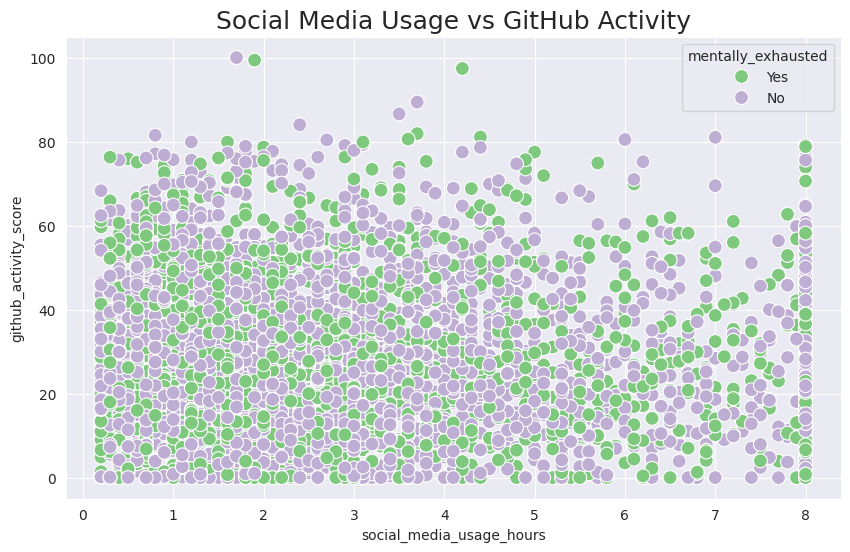

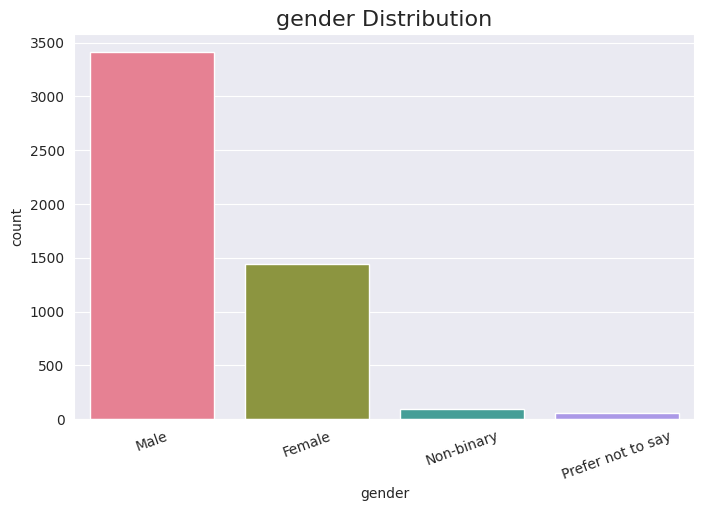

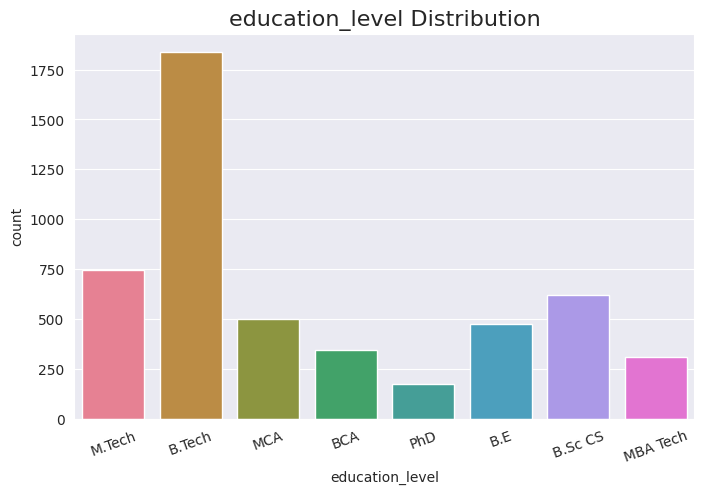

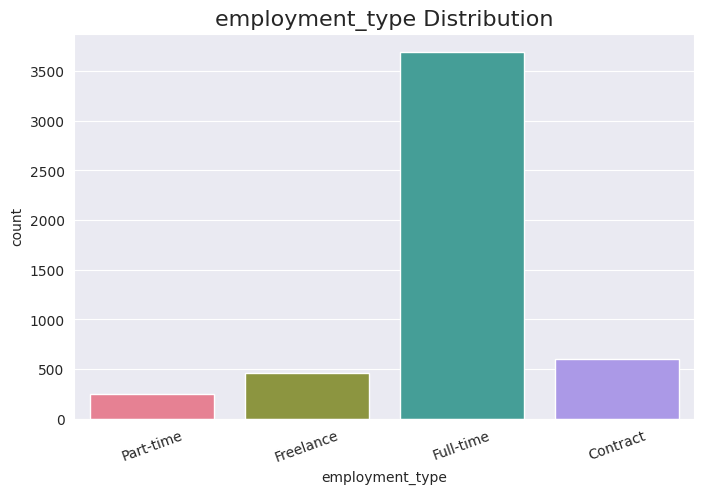

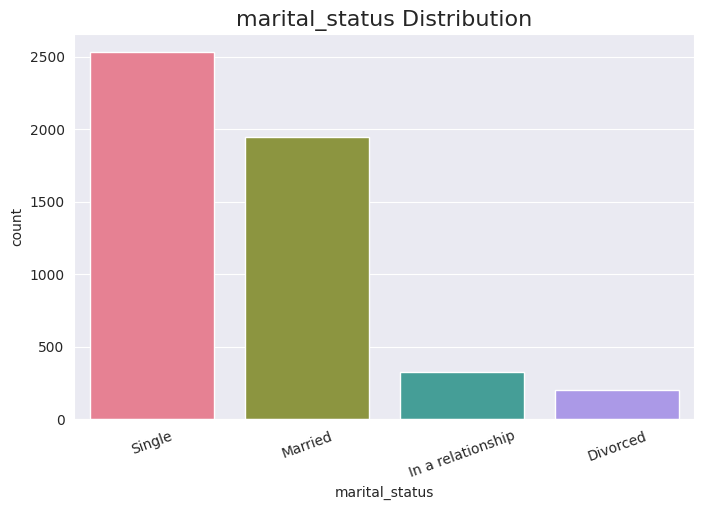

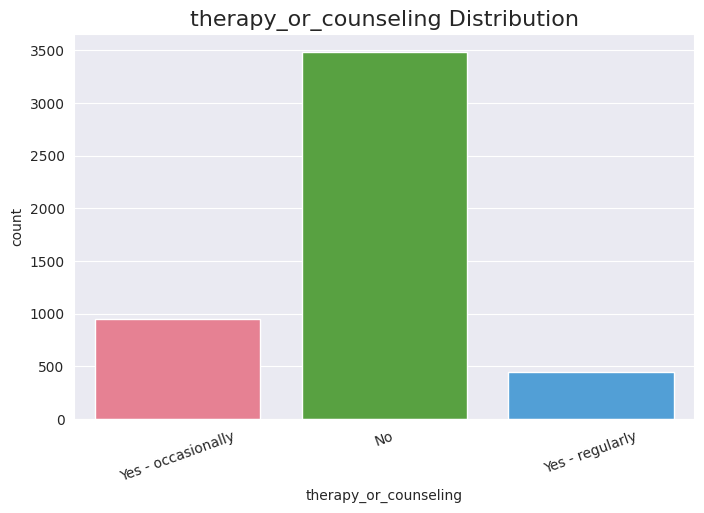

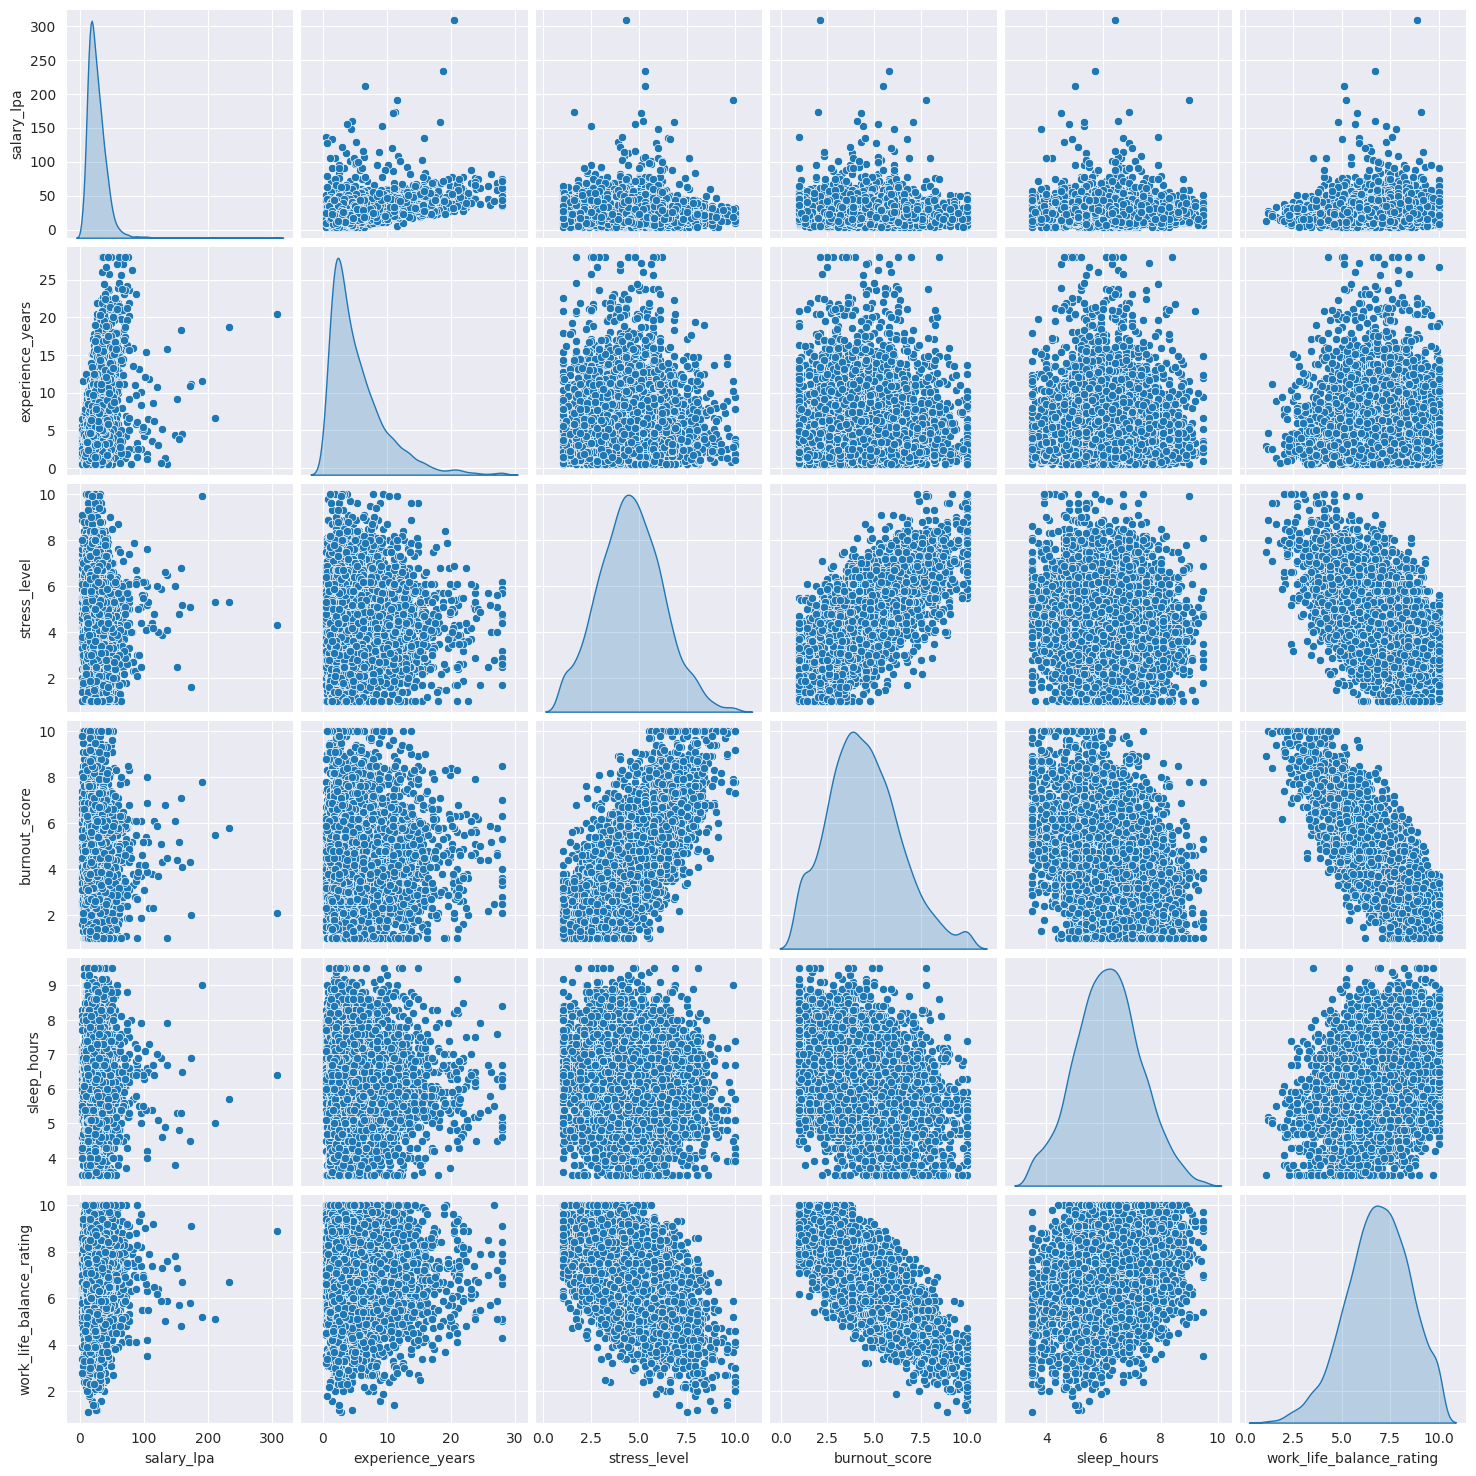

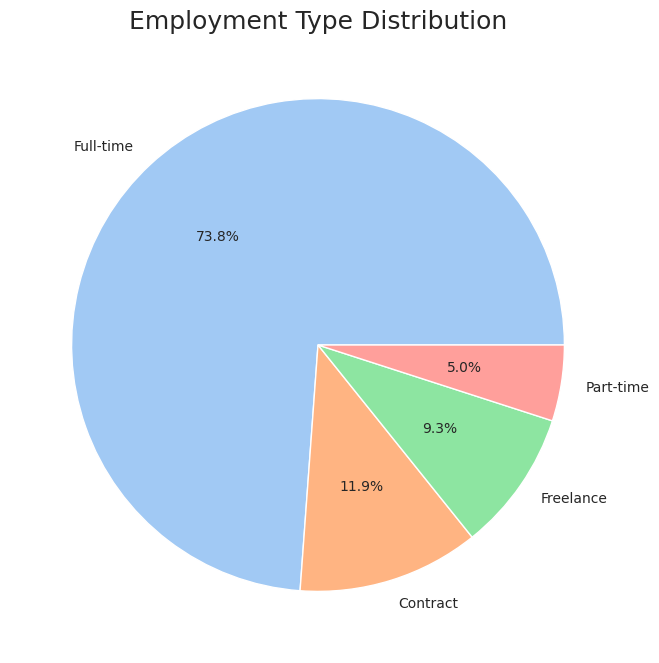

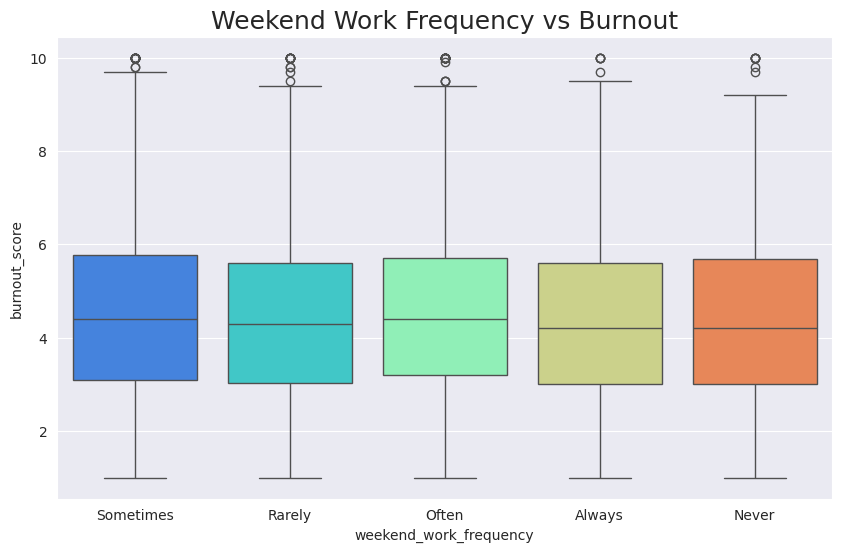

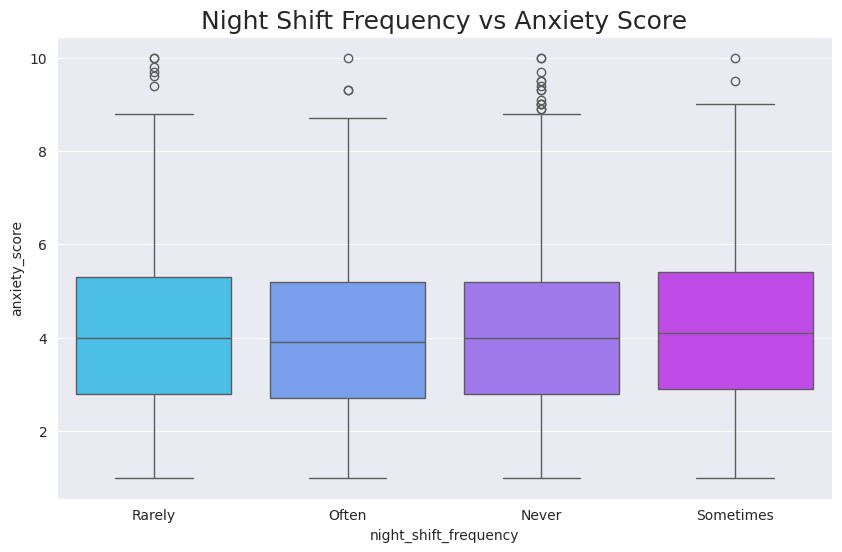

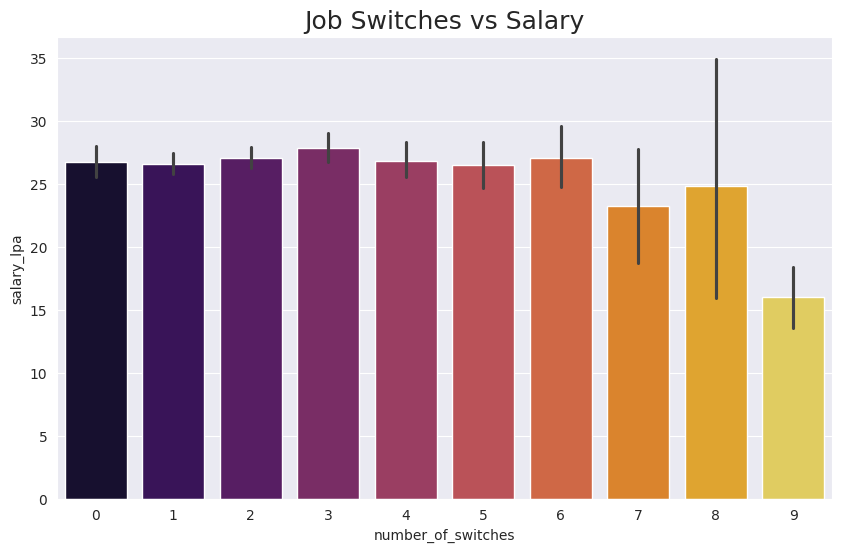

ALL VISUALIZATIONS COMPLETED SUCCESSFULLY


In [12]:
import plotly.express as px
import plotly.graph_objects as go

import missingno as msno


sns.set_style("darkgrid")

plt.rcParams['figure.figsize'] = (12,6)


plt.figure(figsize=(15,6))
msno.bar(df, color='purple')
plt.title("Missing Values Visualization", fontsize=18)
plt.show()

# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

targets = [
    'burnout_risk_category',
    'likely_to_switch_job',
    'mentally_exhausted',
    'high_layoff_risk'
]

for col in targets:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=col,
        palette='Set2'
    )

    plt.title(f"Distribution of {col}", fontsize=16)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=15)

    plt.show()

# ============================================================
# AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['age'],
    bins=25,
    kde=True,
    color='royalblue'
)

plt.title("Age Distribution of Developers", fontsize=18)
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# SALARY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['salary_lpa'],
    bins=30,
    kde=True,
    color='darkgreen'
)

plt.title("Salary Distribution (LPA)", fontsize=18)
plt.xlabel("Salary in LPA")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# STRESS VS BURNOUT
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='stress_level',
    y='burnout_score',
    hue='burnout_risk_category',
    palette='coolwarm',
    s=100
)

plt.title("Stress Level vs Burnout Score", fontsize=18)

plt.show()

# ============================================================
# WORK HOURS VS SLEEP HOURS
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='weekly_work_hours',
    y='sleep_hours',
    hue='mentally_exhausted',
    palette='viridis',
    s=90
)

plt.title("Weekly Work Hours vs Sleep Hours", fontsize=18)

plt.show()

# ============================================================
# WORK LIFE BALANCE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='burnout_risk_category',
    y='work_life_balance_rating',
    palette='Set3'
)

plt.title("Work Life Balance by Burnout Risk", fontsize=18)

plt.show()

# ============================================================
# EXPERIENCE VS SALARY
# ============================================================

plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='experience_years',
    y='salary_lpa',
    scatter_kws={'color':'orange'},
    line_kws={'color':'red'}
)

plt.title("Experience vs Salary", fontsize=18)

plt.show()

# ============================================================
# TOP TECH STACKS
# ============================================================

top_tech = df['tech_stack'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_tech.index,
    y=top_tech.values,
    palette='magma'
)

plt.title("Top 10 Tech Stacks", fontsize=18)

plt.xticks(rotation=45)

plt.ylabel("Count")

plt.show()

# ============================================================
# COMPANY SIZE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='company_size',
    palette='cubehelix'
)

plt.title("Company Size Distribution", fontsize=18)

plt.xticks(rotation=20)

plt.show()

# ============================================================
# REMOTE WORK ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='remote_work_ratio',
    y='stress_level',
    palette='Spectral'
)

plt.title("Remote Work Ratio vs Stress Level", fontsize=18)

plt.show()

# ============================================================
# BURNOUT BY JOB ROLE
# ============================================================

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='job_role',
    y='burnout_score',
    palette='tab20'
)

plt.title("Burnout Score by Job Role", fontsize=18)

plt.xticks(rotation=45)

plt.show()

# ============================================================
# MENTAL HEALTH SCORES CORRELATION
# ============================================================

mental_cols = [
    'stress_level',
    'burnout_score',
    'anxiety_score',
    'imposter_syndrome_score',
    'layoff_anxiety_score',
    'ai_replacement_fear_score'
]

corr = df[mental_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Mental Health Correlation Heatmap", fontsize=18)

plt.show()

# ============================================================
# NUMERICAL FEATURE HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(20,14))

sns.heatmap(
    numeric_df.corr(),
    cmap='RdYlBu',
    linewidths=0.3
)

plt.title("Complete Numerical Correlation Heatmap", fontsize=20)

plt.show()

# ============================================================
# AI TOOL USAGE ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['ai_tools_usage_hours_per_week'],
    bins=25,
    kde=True,
    color='darkcyan'
)

plt.title("AI Tools Usage Hours Per Week", fontsize=18)

plt.show()

# ============================================================
# LEETCODE VS SALARY
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='leetcode_problems_solved',
    y='salary_lpa',
    hue='education_level',
    palette='plasma',
    s=100
)

plt.title("LeetCode Problems Solved vs Salary", fontsize=18)

plt.show()

# ============================================================
# SOCIAL MEDIA VS PRODUCTIVITY
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='social_media_usage_hours',
    y='github_activity_score',
    hue='mentally_exhausted',
    palette='Accent',
    s=100
)

plt.title("Social Media Usage vs GitHub Activity", fontsize=18)

plt.show()

# ============================================================
# CATEGORICAL DISTRIBUTIONS
# ============================================================

categorical_cols = [
    'gender',
    'education_level',
    'employment_type',
    'marital_status',
    'therapy_or_counseling'
]

for col in categorical_cols:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=df,
        x=col,
        palette='husl'
    )

    plt.title(f"{col} Distribution", fontsize=16)

    plt.xticks(rotation=20)

    plt.show()

# ============================================================
# PAIRPLOT OF IMPORTANT FEATURES
# ============================================================

important_cols = [
    'salary_lpa',
    'experience_years',
    'stress_level',
    'burnout_score',
    'sleep_hours',
    'work_life_balance_rating'
]

sns.pairplot(
    df[important_cols],
    diag_kind='kde'
)

plt.show()

# ============================================================
# PIE CHART - EMPLOYMENT TYPE
# ============================================================

employment_counts = df['employment_type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    employment_counts.values,
    labels=employment_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)

plt.title("Employment Type Distribution", fontsize=18)

plt.show()

# ============================================================
# INTERACTIVE PLOTLY VISUALIZATION
# ============================================================

fig = px.scatter(
    df,
    x='experience_years',
    y='salary_lpa',
    color='burnout_risk_category',
    size='stress_level',
    hover_data=['job_role', 'tech_stack'],
    title='Interactive Experience vs Salary Analysis'
)

fig.show()

# ============================================================
# INTERACTIVE 3D VISUALIZATION
# ============================================================

fig = px.scatter_3d(
    df,
    x='stress_level',
    y='sleep_hours',
    z='burnout_score',
    color='burnout_risk_category',
    title='3D Burnout Analysis'
)

fig.show()

# ============================================================
# WEEKEND WORK VS BURNOUT
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='weekend_work_frequency',
    y='burnout_score',
    palette='rainbow'
)

plt.title("Weekend Work Frequency vs Burnout", fontsize=18)

plt.show()

# ============================================================
# NIGHT SHIFT ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='night_shift_frequency',
    y='anxiety_score',
    palette='cool'
)

plt.title("Night Shift Frequency vs Anxiety Score", fontsize=18)

plt.show()

# ============================================================
# JOB SWITCHING ANALYSIS
# ============================================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='number_of_switches',
    y='salary_lpa',
    palette='inferno'
)

plt.title("Job Switches vs Salary", fontsize=18)

plt.show()

# ============================================================
# SAVE FIGURES OPTION
# ============================================================

# Example:
# plt.savefig("figure_name.png", dpi=300, bbox_inches='tight')

# ============================================================
# END OF COMPLETE VISUALIZATION PROJECT
# ============================================================

print("="*60)
print("ALL VISUALIZATIONS COMPLETED SUCCESSFULLY")
print("="*60)

## Feture engineering



TARGET CLASSES
0 : High
1 : Low
2 : Medium


CATEGORICAL COLUMNS
['gender', 'city', 'state', 'marital_status', 'education_level', 'company_type', 'company_size', 'job_role', 'employment_type', 'promotion_last_2_years', 'weekend_work_frequency', 'night_shift_frequency', 'layoffs_seen_in_company', 'primary_language', 'tech_stack', 'therapy_or_counseling', 'linkedin_job_search_activity', 'likely_to_switch_job', 'mentally_exhausted', 'high_layoff_risk']


NUMERICAL COLUMNS
['age', 'experience_years', 'salary_lpa', 'years_in_current_company', 'remote_work_ratio', 'weekly_work_hours', 'number_of_switches', 'ai_tools_usage_hours_per_week', 'upskilling_hours_per_week', 'leetcode_problems_solved', 'certifications_count', 'side_projects_count', 'github_activity_score', 'interview_preparation_hours_weekly', 'stress_level', 'burnout_score', 'anxiety_score', 'sleep_hours', 'caffeine_intake_per_day', 'work_life_balance_rating', 'imposter_syndrome_score', 'social_media_usage_hours', 'physical_activ

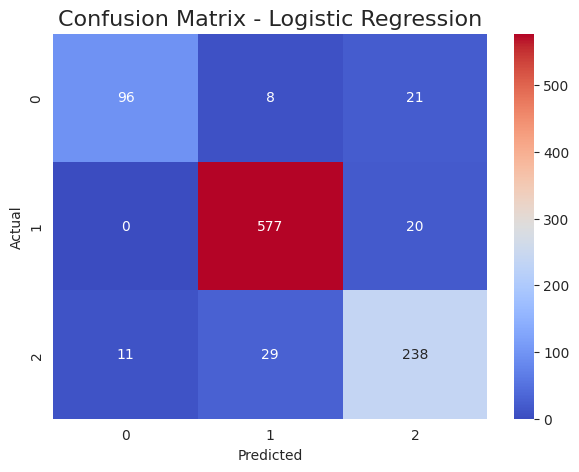

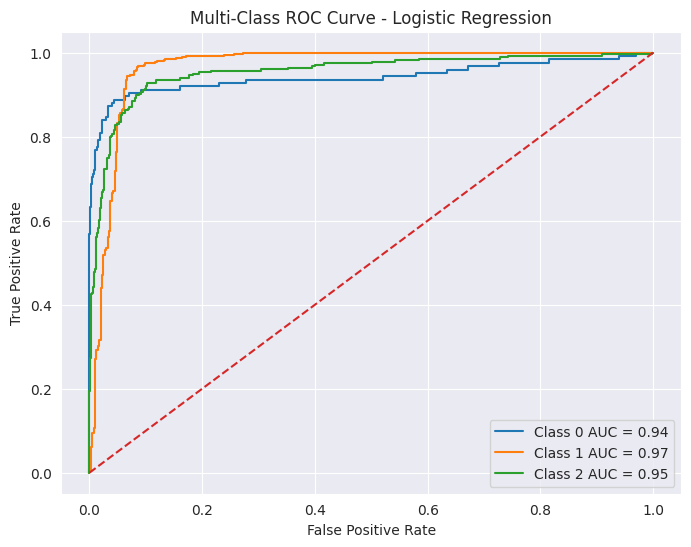



MODEL : Decision Tree

Accuracy Score : 96.2 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       125
           1       0.96      0.99      0.98       597
           2       0.96      0.95      0.95       278

    accuracy                           0.96      1000
   macro avg       0.96      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



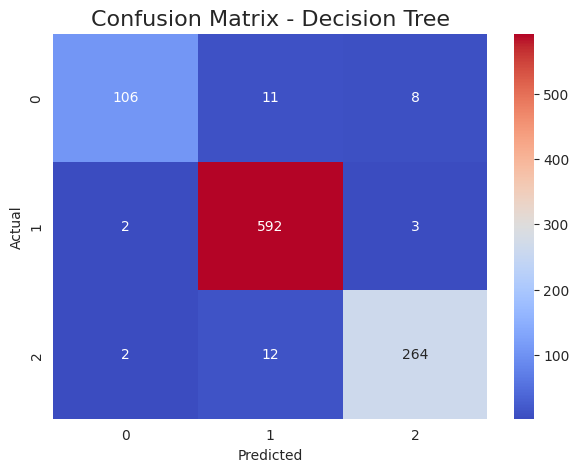

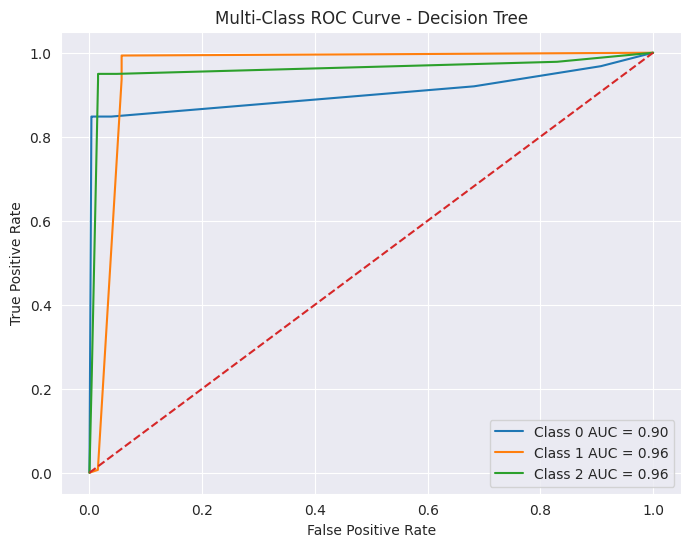



MODEL : Random Forest

Accuracy Score : 96.1 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.81      0.88       125
           1       0.97      0.99      0.98       597
           2       0.93      0.96      0.95       278

    accuracy                           0.96      1000
   macro avg       0.96      0.92      0.94      1000
weighted avg       0.96      0.96      0.96      1000



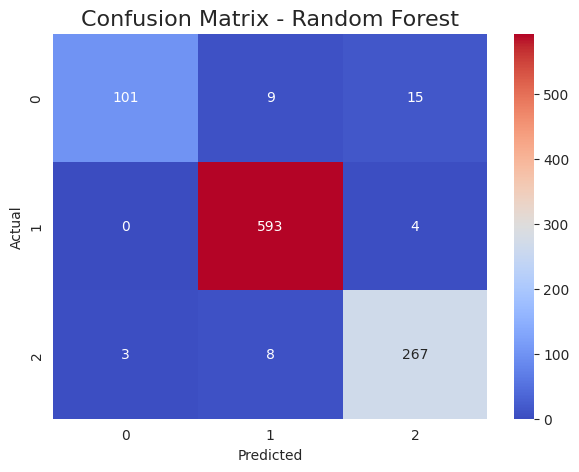

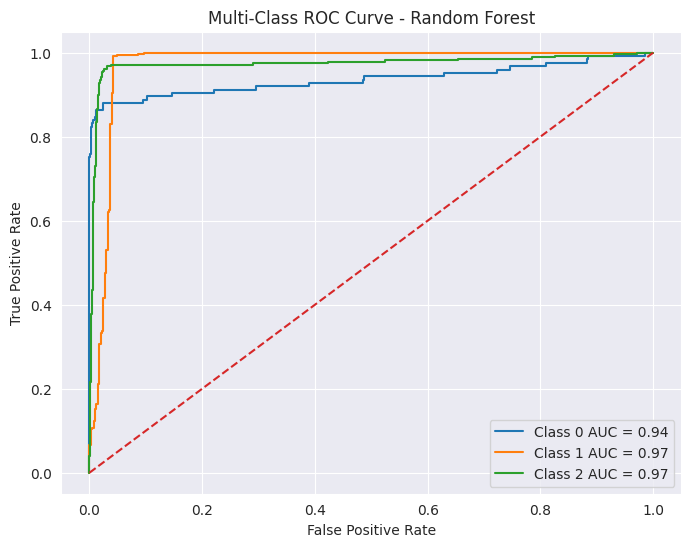



MODEL : Gradient Boosting

Accuracy Score : 97.4 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       1.00      0.88      0.94       125
           1       0.97      0.99      0.98       597
           2       0.97      0.97      0.97       278

    accuracy                           0.97      1000
   macro avg       0.98      0.95      0.96      1000
weighted avg       0.97      0.97      0.97      1000



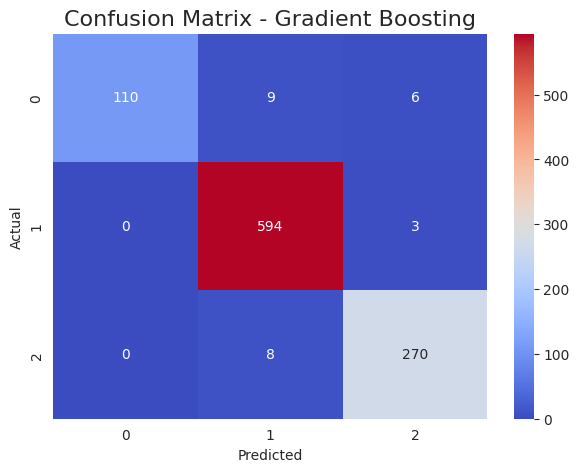

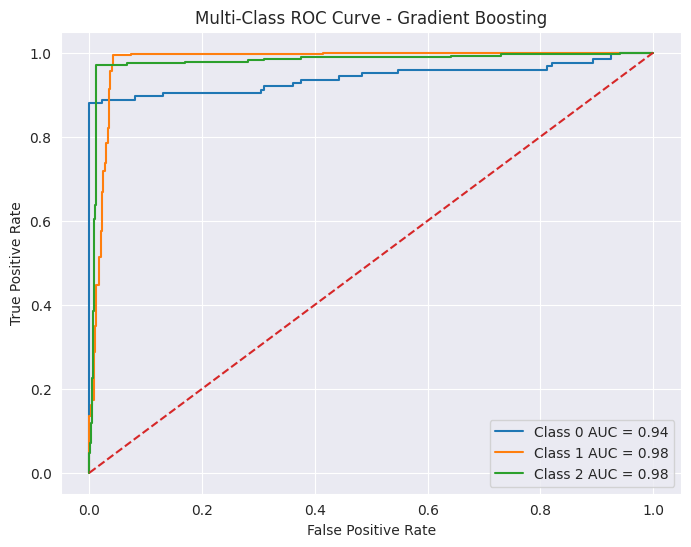



MODEL : KNN

Accuracy Score : 65.7 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.70      0.25      0.37       125
           1       0.70      0.92      0.79       597
           2       0.45      0.28      0.35       278

    accuracy                           0.66      1000
   macro avg       0.62      0.48      0.50      1000
weighted avg       0.63      0.66      0.62      1000



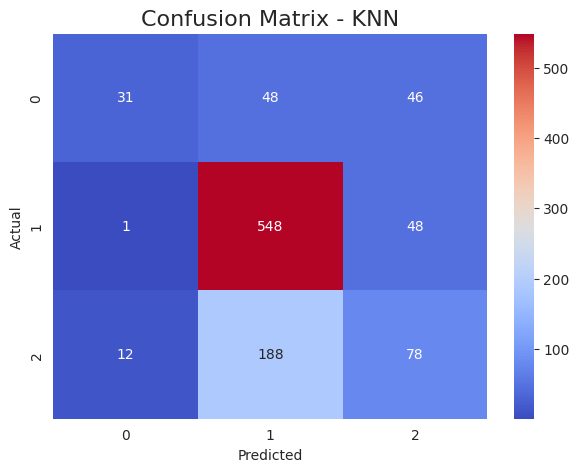

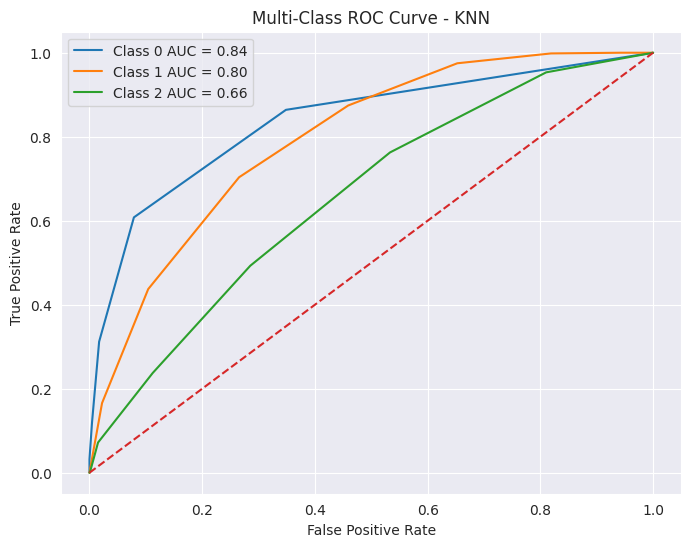



MODEL : SVM

Accuracy Score : 83.8 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.52      0.67       125
           1       0.88      0.94      0.91       597
           2       0.72      0.76      0.74       278

    accuracy                           0.84      1000
   macro avg       0.84      0.74      0.77      1000
weighted avg       0.84      0.84      0.83      1000



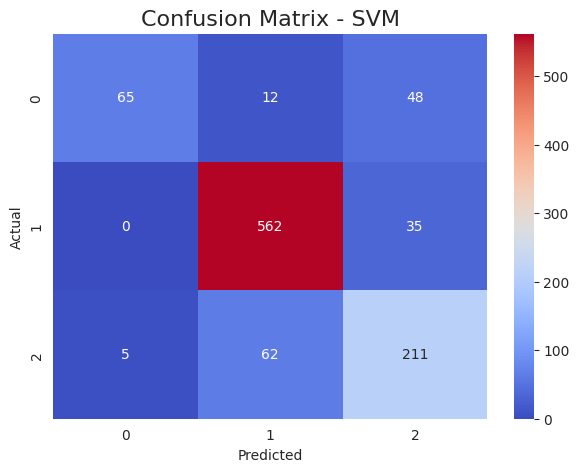

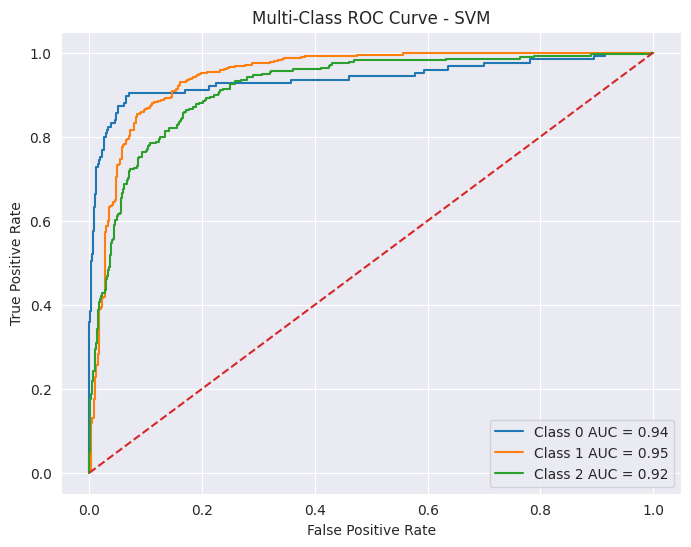



MODEL : Naive Bayes

Accuracy Score : 85.5 %


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       125
           1       0.91      0.90      0.90       597
           2       0.75      0.80      0.77       278

    accuracy                           0.85      1000
   macro avg       0.83      0.82      0.83      1000
weighted avg       0.86      0.85      0.86      1000



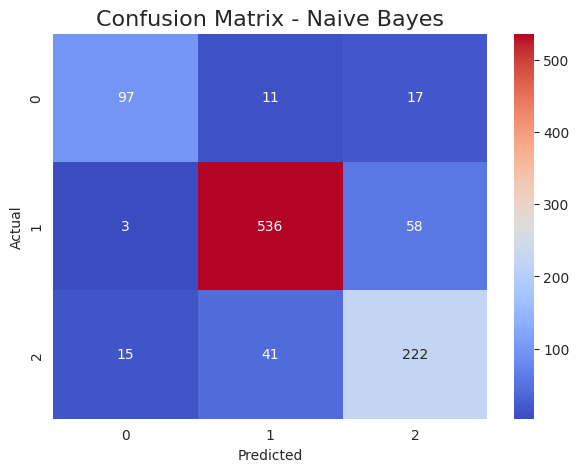

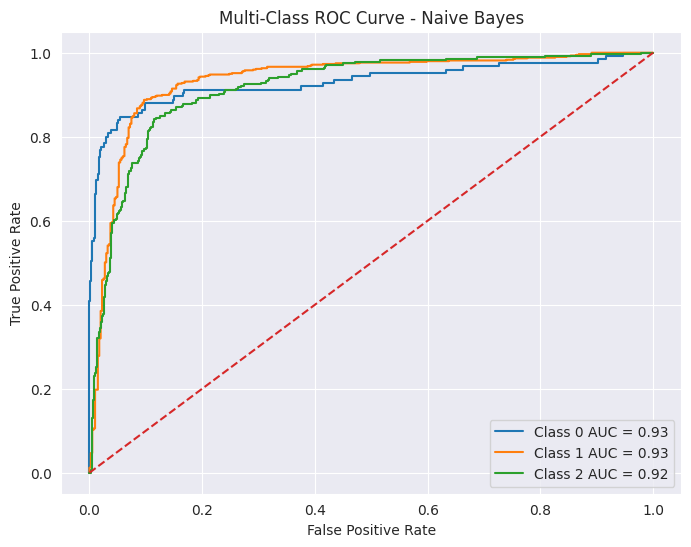



FINAL MODEL ACCURACY COMPARISON
                 Model  Accuracy
3    Gradient Boosting     0.974
1        Decision Tree     0.962
2        Random Forest     0.961
0  Logistic Regression     0.911
6          Naive Bayes     0.855
5                  SVM     0.838
4                  KNN     0.657


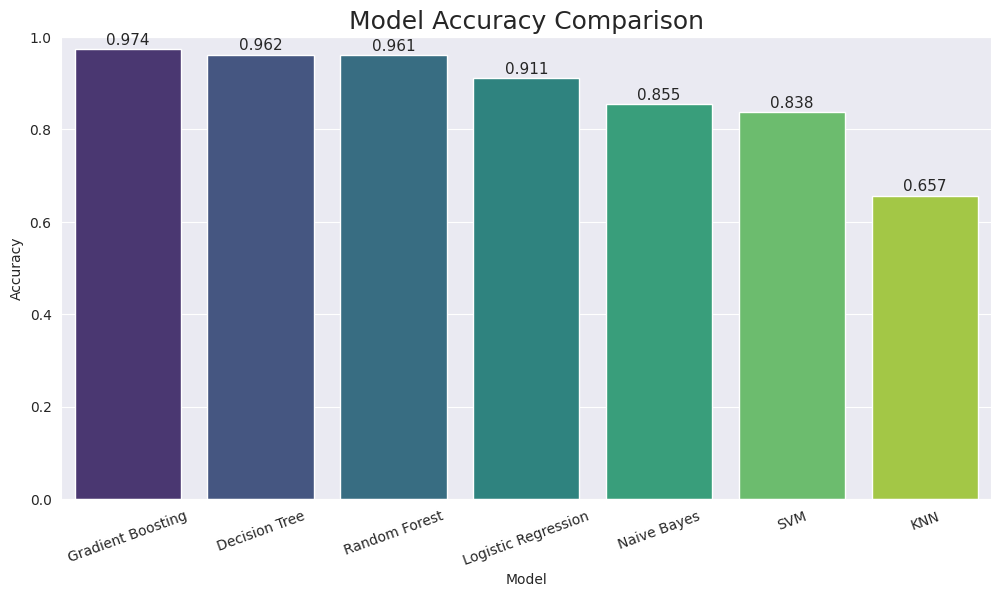



BEST MODEL
Best Model : Gradient Boosting
Best Accuracy : 97.4 %


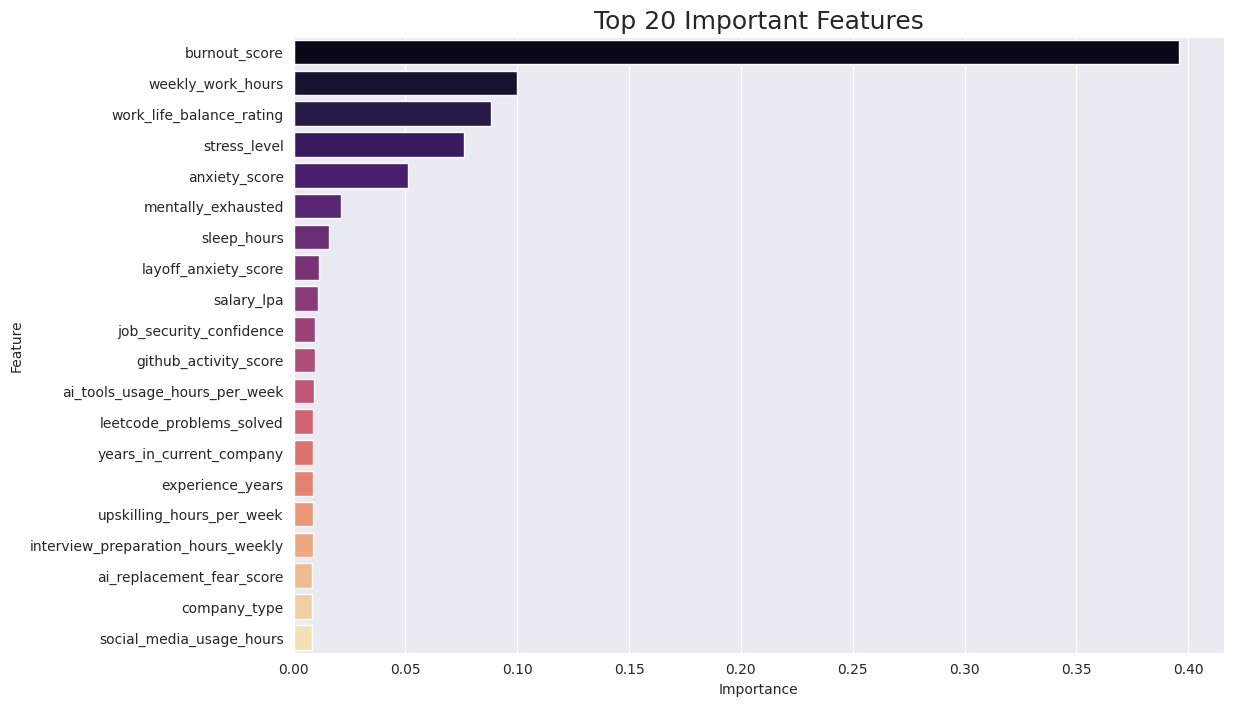



PROJECT COMPLETED SUCCESSFULLY


In [13]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score

from sklearn.preprocessing import label_binarize


df.drop("developer_id", axis=1, inplace=True)


target_column = "burnout_risk_category"


X = df.drop(target_column, axis=1)

y = df[target_column]


target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print("\n")

print("="*60)
print("TARGET CLASSES")
print("="*60)

for i, class_name in enumerate(target_encoder.classes_):
    print(i, ":", class_name)


categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print("\n")

print("="*60)
print("CATEGORICAL COLUMNS")
print("="*60)

print(categorical_cols)

print("\n")

print("="*60)
print("NUMERICAL COLUMNS")
print("="*60)

print(numerical_cols)


# Numerical Pipeline
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', 
     __import__('sklearn').preprocessing.OrdinalEncoder(
         handle_unknown='use_encoded_value',
         unknown_value=-1
     ))

])

# Combine Preprocessing
preprocessor = ColumnTransformer(transformers=[

    ('num', numeric_transformer, numerical_cols),

    ('cat', categorical_transformer, categorical_cols)

])



X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\n")

print("="*60)
print("TRAIN TEST SHAPE")
print("="*60)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(

        max_depth=10,
        random_state=42

    ),

    "Random Forest": RandomForestClassifier(

        n_estimators=200,
        max_depth=12,
        random_state=42

    ),

    "Gradient Boosting": GradientBoostingClassifier(

        n_estimators=150,
        learning_rate=0.1,
        random_state=42

    ),

    "KNN": KNeighborsClassifier(

        n_neighbors=7

    ),

    "SVM": SVC(

        probability=True,
        kernel='rbf',
        random_state=42

    ),

    "Naive Bayes": GaussianNB()

}


accuracy_results = {}



for model_name, model in models.items():

    print("\n")
    print("="*70)
    print("MODEL :", model_name)
    print("="*70)

    # Create Full Pipeline
    clf = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # ========================================================
    # TRAIN MODEL
    # ========================================================

    clf.fit(X_train, y_train)

    # ========================================================
    # PREDICTION
    # ========================================================

    y_pred = clf.predict(X_test)

    # ========================================================
    # ACCURACY
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    accuracy_results[model_name] = accuracy

    print("\nAccuracy Score :", round(accuracy * 100, 2), "%")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\n")

    print("="*50)
    print("CLASSIFICATION REPORT")
    print("="*50)

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='coolwarm'

    )

    plt.title(f"Confusion Matrix - {model_name}", fontsize=16)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    if len(np.unique(y)) == 2:

        # Binary Classification

        y_prob = clf.predict_proba(X_test)[:,1]

        fpr, tpr, thresholds = roc_curve(y_test, y_prob)

        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8,6))

        plt.plot(

            fpr,
            tpr,
            label=f"AUC = {roc_auc:.3f}"

        )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"ROC Curve - {model_name}", fontsize=16)

        plt.legend()

        plt.show()

        print("ROC AUC Score :", round(roc_auc, 4))

    else:

        # Multi-Class Classification

        y_prob = clf.predict_proba(X_test)

        y_test_bin = label_binarize(

            y_test,

            classes=np.unique(y)

        )

        plt.figure(figsize=(8,6))

        for i in range(len(np.unique(y))):

            fpr, tpr, _ = roc_curve(

                y_test_bin[:, i],
                y_prob[:, i]

            )

            roc_auc = auc(fpr, tpr)

            plt.plot(

                fpr,
                tpr,
                label=f"Class {i} AUC = {roc_auc:.2f}"

            )

        plt.plot([0,1], [0,1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(f"Multi-Class ROC Curve - {model_name}")

        plt.legend()

        plt.show()

# ============================================================
# FINAL ACCURACY COMPARISON
# ============================================================

results_df = pd.DataFrame({

    "Model": accuracy_results.keys(),

    "Accuracy": accuracy_results.values()

})

results_df = results_df.sort_values(

    by="Accuracy",
    ascending=False

)

print("\n")

print("="*70)
print("FINAL MODEL ACCURACY COMPARISON")
print("="*70)

print(results_df)

# ============================================================
# VISUALIZE ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x='Model',

    y='Accuracy',

    palette='viridis'

)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

for index, value in enumerate(results_df['Accuracy']):

    plt.text(

        index,
        value + 0.01,

        str(round(value, 3)),

        ha='center',
        fontsize=11

    )

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]['Model']

best_accuracy = results_df.iloc[0]['Accuracy']

print("\n")

print("="*70)
print("BEST MODEL")
print("="*70)

print("Best Model :", best_model_name)

print("Best Accuracy :", round(best_accuracy * 100, 2), "%")

# ============================================================
# FEATURE IMPORTANCE
# RANDOM FOREST
# ============================================================

rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(

        n_estimators=200,
        random_state=42

    ))

])

rf_pipeline.fit(X_train, y_train)

# ============================================================
# GET FEATURE NAMES
# ============================================================

encoded_cat_names = categorical_cols

all_feature_names = numerical_cols + encoded_cat_names

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

feature_importance = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({

    'Feature': all_feature_names,

    'Importance': feature_importance

})

importance_df = importance_df.sort_values(

    by='Importance',
    ascending=False

).head(20)

# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

plt.figure(figsize=(12,8))

sns.barplot(

    data=importance_df,

    x='Importance',

    y='Feature',

    palette='magma'

)

plt.title("Top 20 Important Features", fontsize=18)

plt.show()

# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(

    "model_accuracy_results.csv",

    index=False

)

print("\n")

print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)